In [49]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

#### Correzzioni degli offset.


Nella correzione Lente 1, offset_LENTE1_A e offset_LENTE1_B rappresentano rispettivamente la distanza tra l'asse del carrellino e V e la distanza tra l asse del carrellino e V'.

VV_LENTE1 è la distanza VV' data come specifica della lente (c'è una piccola incongruenza dato che la somma di offset_A e offset_B non è uguale a VV).

In offset_LENTE1_q e offset_LENTE1_p il primo e secondo termine se sommati definiscono l'offset dell'asse della lente (che non combacia con l'asse del carrellino) mentre VV/3 rappresenta l'offset dovuto alla distanza tra asse della lente e i piani principali.

In offset_LENTE2 avremmo dovuto applicare lo stesso concetto ma, non avendo a disposizione una misura paragonabile a offset_A e offset_B ma per la lente 2, si preferisce approssimare il centro della lente come coincidente al centro del carrellino.

In [50]:
#Correzione distanza oggetto
offset_OGGETTO = 74.0

#Correzione Lente 1:
offset_LENTE1_A = 7.5
offset_LENTE1_B = 0.6
VV_LENTE1 = 7.2
offset_LENTE1_p = 25.4/2 - (offset_LENTE1_A - offset_LENTE1_B)/2 - VV_LENTE1/3
offset_LENTE1_q = 25.4/2 - (offset_LENTE1_A - offset_LENTE1_B)/2 + VV_LENTE1/3

#Correzione Lente 2:
offset_LENTE2_A = 0
offset_LENTE2_B = 0
VV_LENTE2 = 10.1
offset_LENTE1_p = 25.4/2 - (offset_LENTE1_A - offset_LENTE1_B)/2 - VV_LENTE1/3
offset_LENTE1_q = 25.4/2 - (offset_LENTE1_A - offset_LENTE1_B)/2 + VV_LENTE1/3

#Correzione CCD: 
offset_CCD = 15.7
#Correzione dei dati del secondo giorno (in realtà terzo) per la rotazione della mascherina
offset_GIORNO2 = - 7
#Lunghezza totale (per Bessel)
lunghezza = 561

# 1. Punti Coniugati


In [51]:
metodo = "Coniugati"

### 1.1 Lettura

In [52]:
def nome (stringa, cartella):
    """
    Estrae il nome dal titolo di ogni file input letto
    """
    
    stringa_nuova = stringa.replace(f'./Data/{cartella}/dati_','').replace('.csv','')
    return stringa_nuova

In [53]:
input_files = [f"./Data/{metodo}/{nome_file}" for nome_file in sorted(os.listdir(f'./Data/{metodo}'))]
data1 = {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    data1[nome(input_file, metodo)] = {
        "immagine": letti["immagine"],
        "lente": letti["lente"],
    }

### 1.2 Analisi

$$
Y = \frac{1}{f} - X
$$

$$
\frac{1}{x_{lente}} = \frac{1}{f} - \frac{1}{x_{immagine}}
$$

Le incertezze usate sono state stimate come risoluzione (0.5mm) fratto il quadrato della misura: questo è dovuto alla propagazione delle incertezze per il reciproco di un valore.

In [54]:
distanze = {}
focali1 = {}

for colore,dati in data1.items():
    if colore=="rosso":
        p = np.array(dati["lente"]) + offset_OGGETTO + offset_GIORNO2 + offset_LENTE1_p
    else:
        p = np.array(dati["lente"]) + offset_OGGETTO + offset_LENTE1_p
    q = np.array(dati["immagine"]) - (np.array(dati["lente"]) + offset_LENTE1_q) + offset_CCD

    anal = f.elaborato(1/q, 1/p, 0.5/(p*p), "elaborato_coniugati.txt", 0, vsx = 0.5/(q*q), ritorno = True)

    print(f"b = {anal[1]}")
        
    print(f"p-value = {anal[5]}")

    distanze[colore] = {
        "p" : p,
        "q" : q,
    }

    focali1[colore] = {
        "f" : 1/anal[0],
        "sf" : anal[2]/anal[0]**2
    }


Elaborazione serie 1
	Incertezze x variabili
	Incertezze y variabili
	Minimi quadrati 3
b = -0.9661513206594893
p-value = 9.779597962096344e-79

Elaborazione serie 1
	Incertezze x variabili
	Incertezze y variabili
	Minimi quadrati 3
b = -1.0145800257944473
p-value = 5.082807640692511e-56

Elaborazione serie 1
	Incertezze x variabili
	Incertezze y variabili
	Minimi quadrati 3
b = -0.9835449954511135
p-value = 0.862697446225986


### 1.3 Grafici

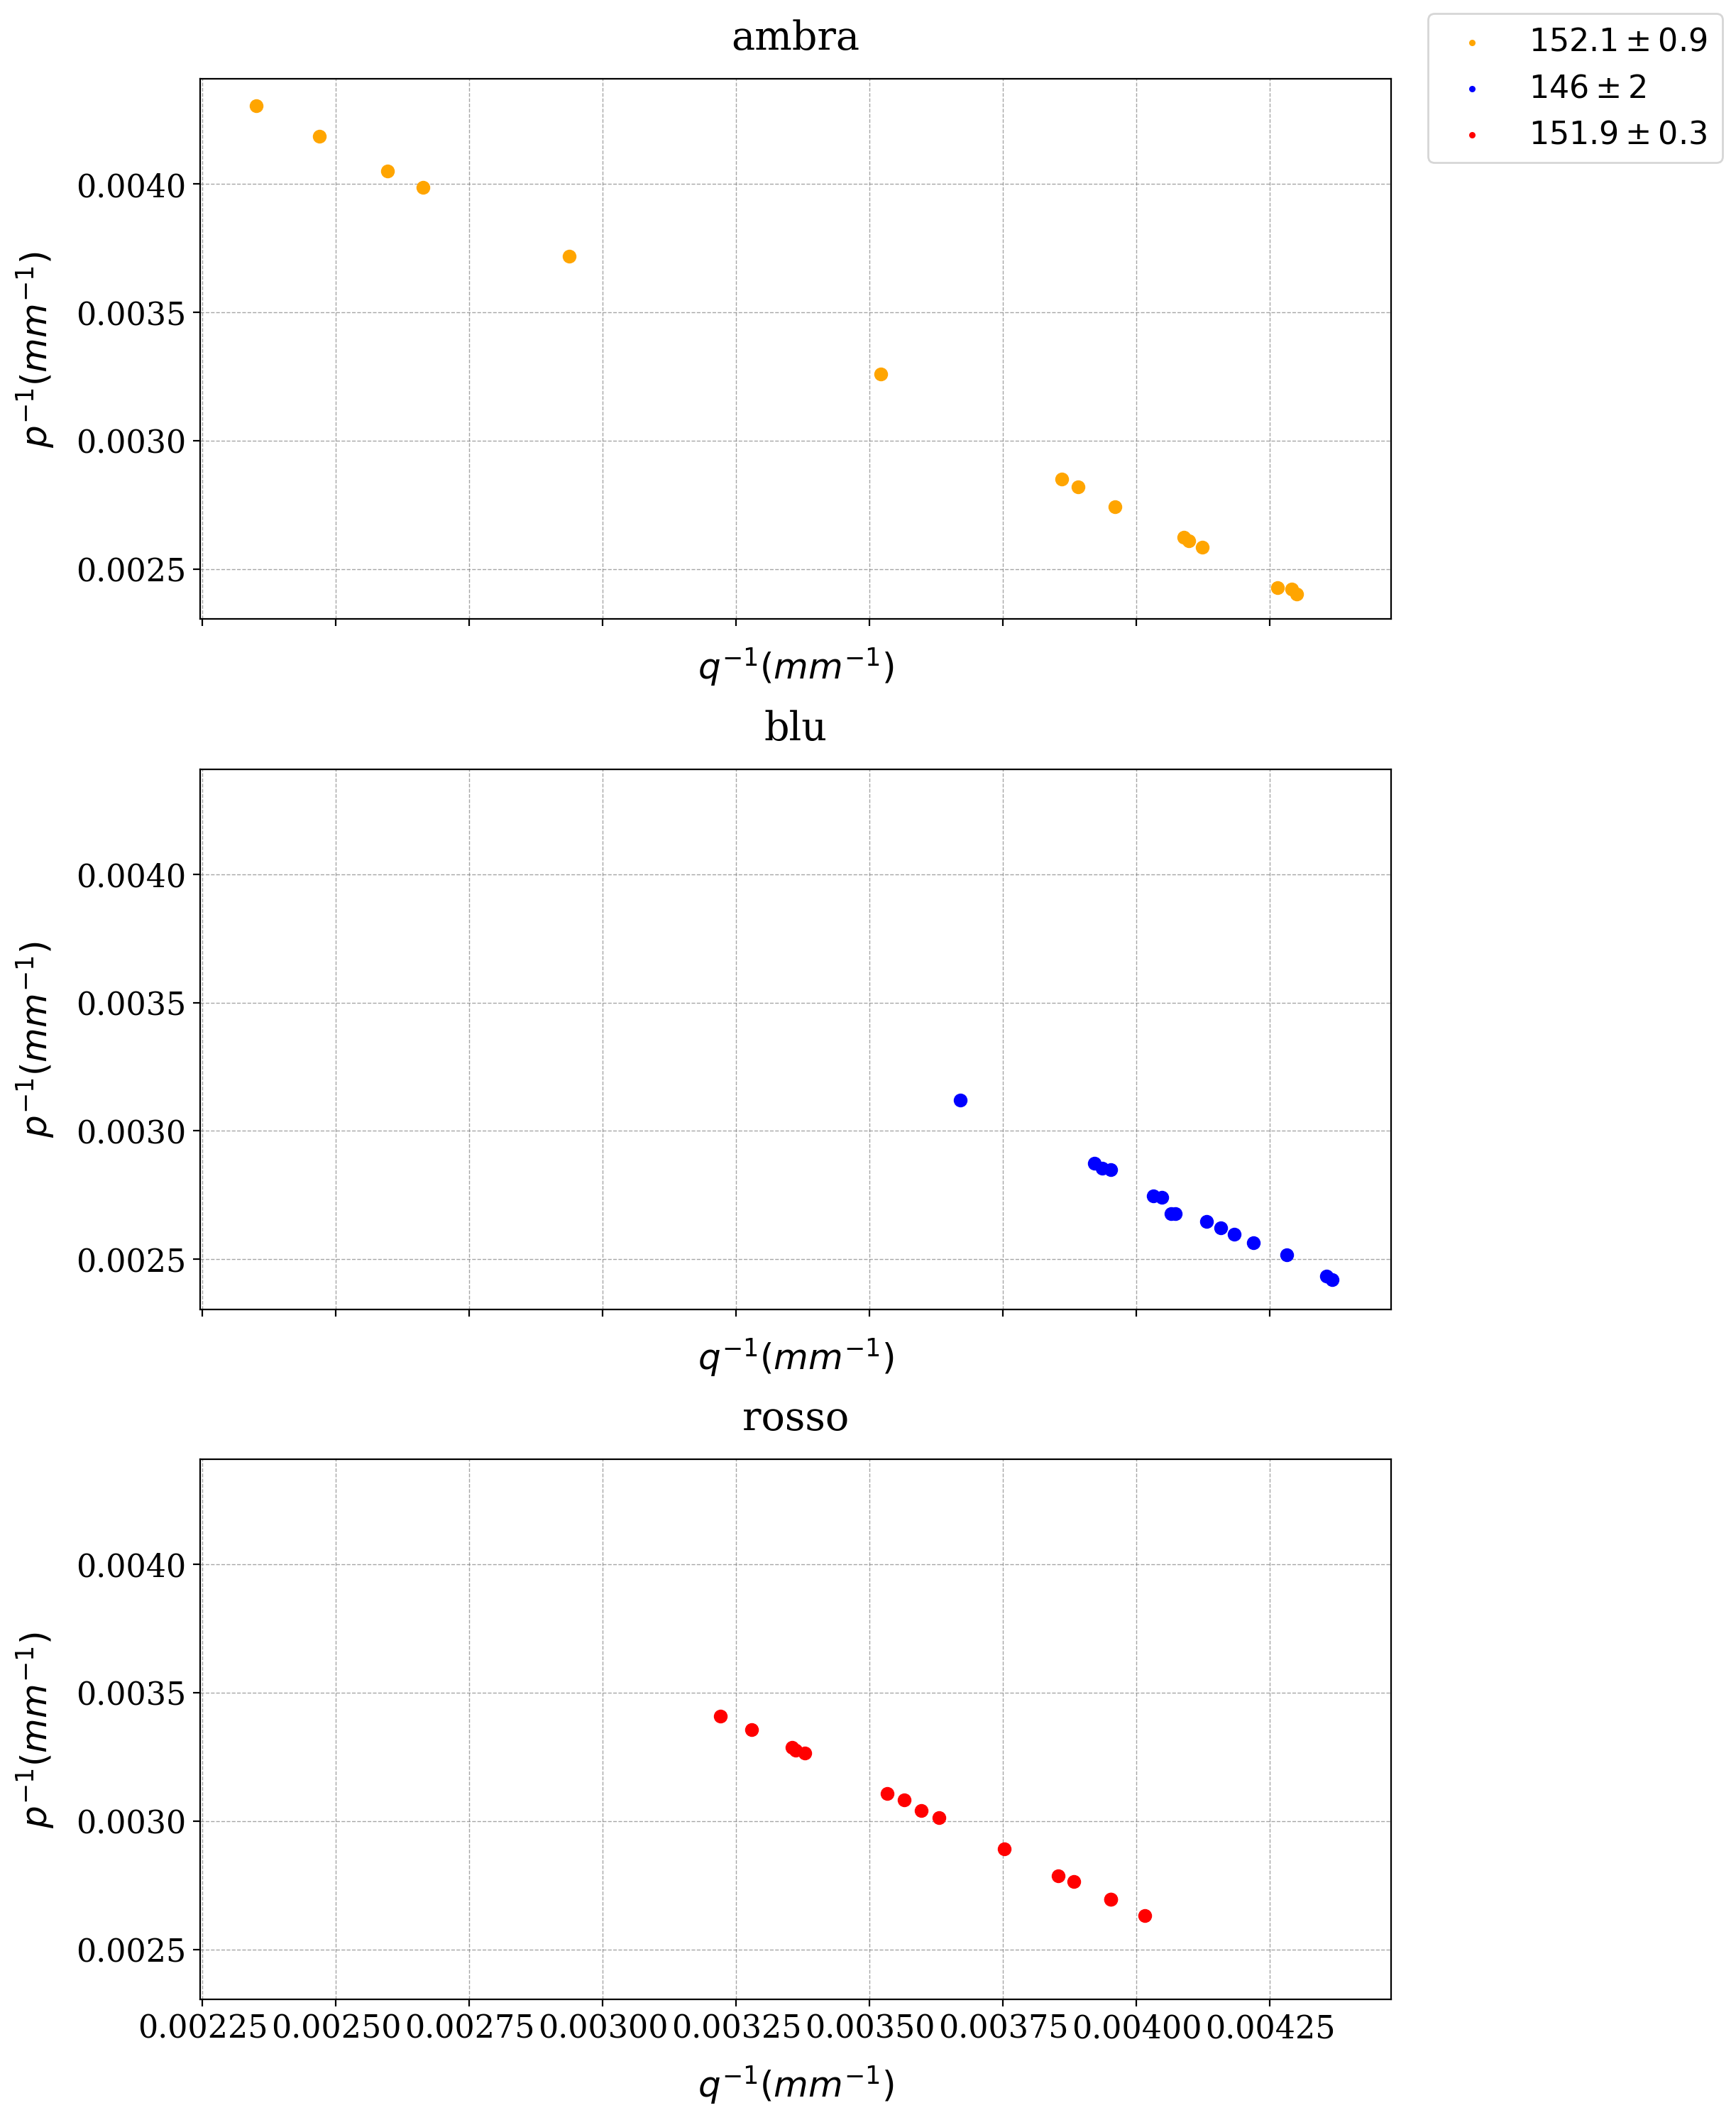

In [55]:
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, len(input_files)*5), sharex=True, sharey=True)

ax = axes

titolo = "Test"

for i, (input_file, distanza, focali) in enumerate(zip(input_files, distanze.values(), focali1.values())):

    ax = axes[i]

    titolo = nome(input_file, metodo)
    if i == 0 : colore = "orange"
    elif i == 1 : colore = "blue"
    elif i == 2 : colore = "red"

    p = distanza["p"]
    q = distanza["q"]

    ax.errorbar(1/q, 1/p, xerr = 0.5/(q*q) , yerr = 0.5/(p*p), color=colore, fmt = 'o')
    #meme.scrivi(ax,"CHE SCHIFO", densita=1000)
    #gf.numera_punti(ax,q,p)

    stringa_f = gf.formatta_errore(focali["f"],focali["sf"])

    gf.parametri_grafico(ax, titolo, "$q^{-1}(mm^{-1})$", "$p^{-1}(mm^{-1})$")
    gf.descrizione_legenda(ax, stringa_f, color=colore)
gf.salva_grafico(fig, "grafici_coniugati.pdf")

# 2. Bessel

In [56]:
metodo = "Bessel"

### 2.1 Lettura

In [57]:
input_files = [f"./Data/{metodo}/{nome_file}" for nome_file in sorted(os.listdir(f'./Data/{metodo}'))]
data2 = {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    data2[nome(input_file, metodo)] = {
        "pl+": letti["pl+"],
        "pl-": letti["pl-"],
    }

### 2.2 Analisi

In [66]:
focali2 = {}

L = lunghezza + offset_OGGETTO + offset_CCD
L0 = L

for colore,dati in data2.items():

    if colore=="rosso" : L = L0 + offset_GIORNO2

    pl_piu = np.mean(np.array(dati["pl+"]))
    pl_meno = np.mean(np.array(dati["pl-"]))
    s_pl_piu = f.s_media(dati["pl+"])
    s_pl_meno = f.s_media(dati["pl-"])
    ritorno = f.propaga_incertezza("(L**2 - (pl_piu - pl_meno)**2) / (4 * L)", ["L","pl_piu","pl_meno"],
                     valori = [L, pl_piu, pl_meno],
                     incertezze = [0.5/np.sqrt(12), s_pl_piu, s_pl_meno],
                     ritorno = True)
    focali2[colore] = {
        "f" : (L**2 - (pl_piu - pl_meno)**2) / (4 * L),
        "sf" : ritorno[0],
        }
L = L0

In [67]:
gf.display_dizionario(focali1)

In [68]:
gf.display_dizionario(focali2)

In [73]:
import numpy as np

def compatibilita(f1, sf1, f2, sf2):
    f1 = float(f1)
    sf1 = float(sf1)
    f2 = float(f2)
    sf2 = float(sf2)
    return abs(f1 - f2) / np.sqrt(sf1**2 + sf2**2)

z_scores = {}

for colore in focali1.keys():
    f1 = focali1[colore]["f"]
    sf1 = focali1[colore]["sf"]
    f2 = focali2[colore]["f"]
    sf2 = focali2[colore]["sf"]

    z = compatibilita(f1, sf1, f2, sf2)
    z_scores[colore] = z

for colore, z in z_scores.items():
    print(f"{colore}: z = {z:.3f}")


ambra: z = 2.184
blu: z = 1.070
rosso: z = 0.370


# 3. Aberrazione

In [61]:
metodo = "Aberrazione"

### 3.1 Lettura

In [62]:
input_files = [f"./Data/{metodo}/{nome_file}" for nome_file in sorted(os.listdir(f'./Data/{metodo}'))]
data3 = {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    data3[nome(input_file, metodo)] = {
        "parassiale": letti["parassiale"],
        "marginale": letti["marginale"],
    }

In [63]:
gf.display_dizionario(data3)

### 3.2 Analisi

In [64]:
aberrazione_sferica = {}

for colore,dati in data3.items():

    f_marginale = np.mean(np.array(dati["marginale"]))
    f_parassiale = np.mean(np.array(dati["parassiale"]))
    s_f_marginale = f.s_media(dati["marginale"])
    s_f_parassiale = f.s_media(dati["parassiale"])
    ritorno = f.propaga_incertezza("f_parassiale - f_marginale", ["f_parassiale", "f_marginale"],
                     valori = [f_parassiale, f_marginale],
                     incertezze = [s_f_parassiale, s_f_parassiale],
                     ritorno = True)
    aberrazione_sferica[colore] = {
        "aberrazione_sferica" : f_parassiale - f_marginale,
        "s_aberrazione_sferica" : ritorno[0],
        }

In [65]:
gf.display_dizionario(aberrazione_sferica)